### TASK:
* contrast enhancement
* image enhancement

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from core.entities.constants import Paths as p

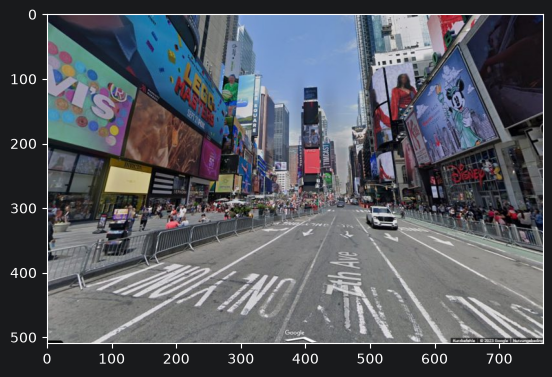

In [2]:
img_path = p.IMAGE_ASSETS / "street.jpg"
img = cv2.imread(img_path, cv2.IMREAD_COLOR_RGB)
plt.figure()
plt.imshow(img)

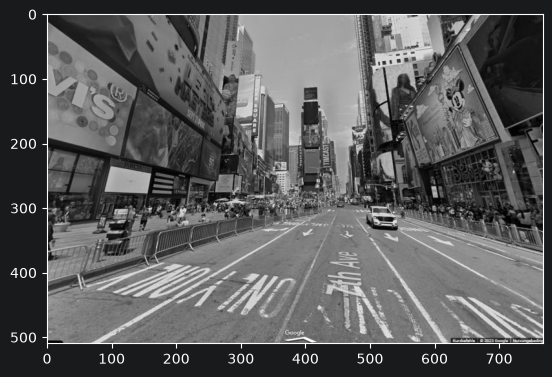

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure()
plt.imshow(gray, cmap="gray")

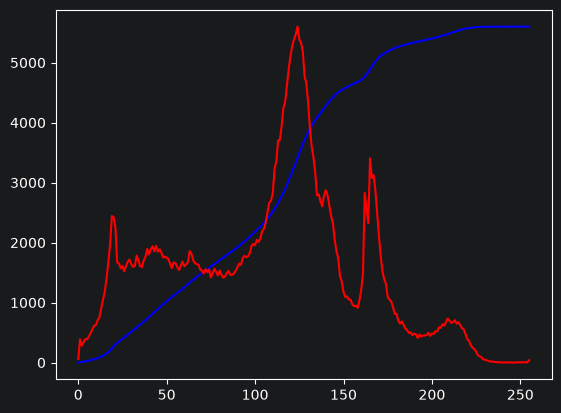

In [4]:
orig_hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
orig_cdf = orig_hist.cumsum()
orig_cdf_norm = orig_cdf * float(orig_hist.max()) / orig_cdf.max()

plt.figure()
plt.plot(orig_cdf_norm, color="b")
plt.plot(orig_hist, color="r")

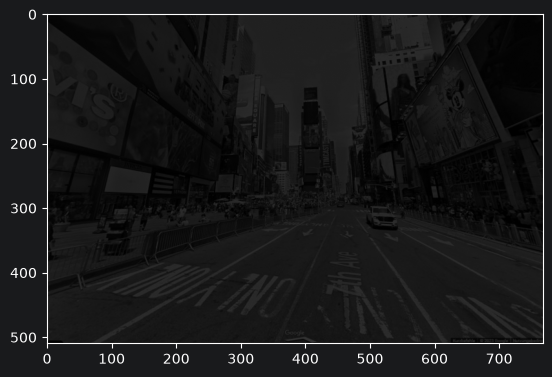

In [5]:
bad_quality_gray = (gray * 0.2).astype(np.uint8)

plt.figure()
plt.imshow(bad_quality_gray, cmap="gray", vmin=0, vmax=255)


Text(0, 0.5, '# of Pixels')

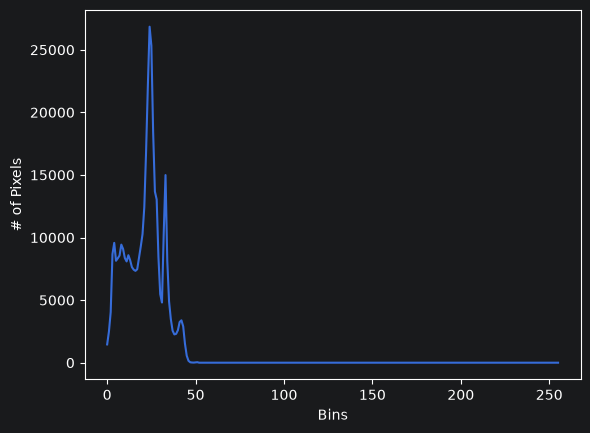

In [6]:
hist = cv2.calcHist([bad_quality_gray], [0], None, [256], [0, 256])
plt.figure()
plt.plot(hist)
plt.xlabel("Bins")
plt.ylabel("# of Pixels")

Text(0, 0.5, '# of Pixels')

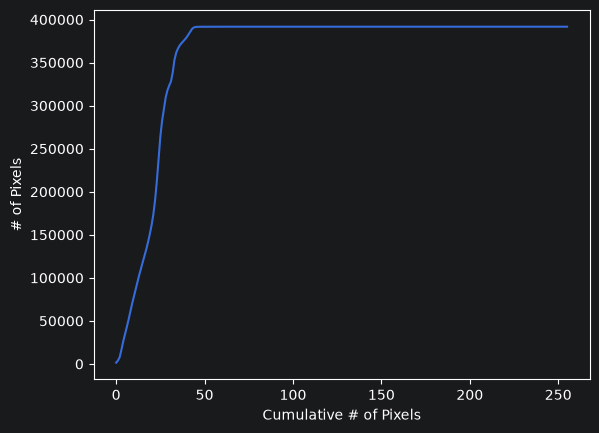

In [7]:
cdf = hist.cumsum()
plt.figure()
plt.plot(cdf)
plt.xlabel("Cumulative # of Pixels")
plt.ylabel("# of Pixels")

Text(0, 0.5, 'pixel counts')

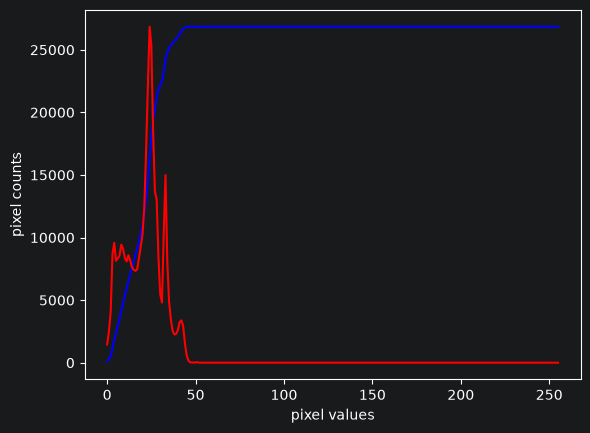

In [8]:
# normalize cdf values to hist values range
cdf_norm = cdf * float(hist.max()) / cdf.max()
plt.figure()
plt.plot(cdf_norm, color="b")
plt.plot(hist, color="r")
plt.xlabel("pixel values")
plt.ylabel("pixel counts")


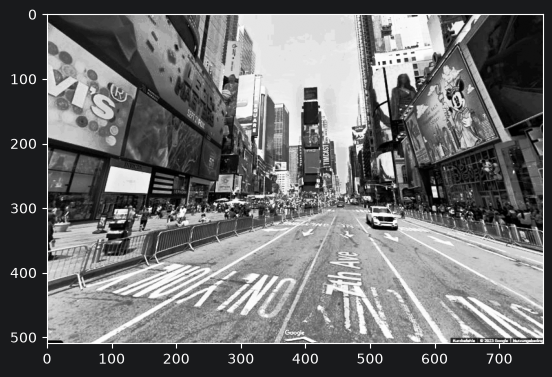

In [9]:
equ_image = cv2.equalizeHist(bad_quality_gray)

plt.figure()
plt.imshow(equ_image, cmap="gray", vmin=0, vmax=255)


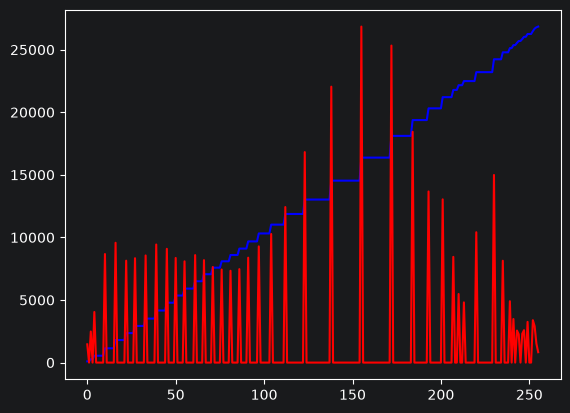

In [10]:
equ_hist = cv2.calcHist([equ_image], [0], None, [256], [0, 256])
equ_cdf = equ_hist.cumsum()
equ_cdf_norm = equ_cdf * float(equ_hist.max()) / equ_cdf.max()
plt.figure()
plt.plot(equ_cdf_norm, color="b")
plt.plot(equ_hist, color="r")

# CLAHE

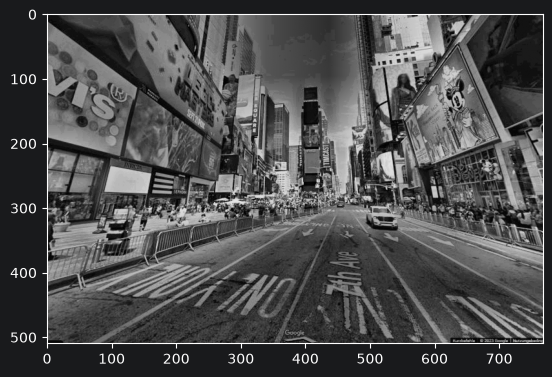

In [11]:
clahe_obj = cv2.createCLAHE(clipLimit=8.0, tileGridSize=(8, 8))
clahe_img = clahe_obj.apply(bad_quality_gray)
plt.figure()
plt.imshow(clahe_img, cmap="gray", vmin=0, vmax=255)

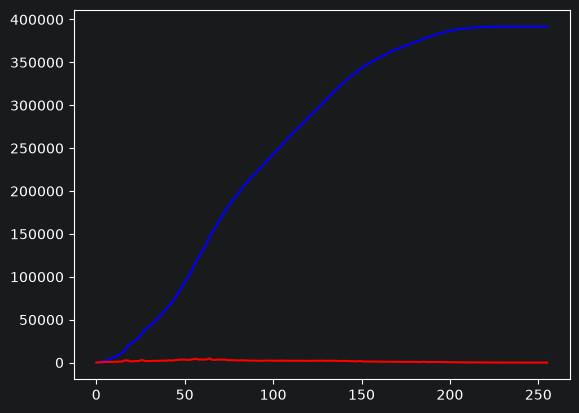

In [12]:
clahe_hist = cv2.calcHist([clahe_img], [0], None, [256], [0, 256])
clahe_cdf = clahe_hist.cumsum()
clahe_cdf_norm = clahe_cdf + float(clahe_hist.max()) / clahe_cdf.max()

plt.figure()
plt.plot(clahe_cdf_norm, color="b")
plt.plot(clahe_hist, color="r")

([], [])

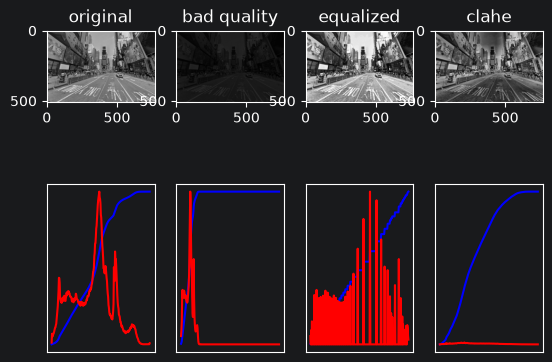

In [13]:
plt.figure()

# original
plt.subplot(241)
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.title("original")

plt.subplot(245)
plt.plot(orig_cdf_norm, color="b")
plt.plot(orig_hist, color="r")
plt.xticks([])
plt.yticks([])
# bad_quality
plt.subplot(242)
plt.imshow(bad_quality_gray, cmap="gray", vmin=0, vmax=255)
plt.title("bad quality")
plt.subplot(246)
plt.plot(cdf_norm, color="b")
plt.plot(hist, color="r")
plt.xticks([])
plt.yticks([])
# equalized
plt.subplot(243)
plt.imshow(equ_image, cmap="gray", vmin=0, vmax=255)
plt.title("equalized")
plt.subplot(2, 4, 7)
plt.plot(equ_cdf_norm, color="b")
plt.plot(equ_hist, color="r")
plt.xticks([])
plt.yticks([])
# CLAHE
plt.subplot(2, 4, 4)
plt.imshow(clahe_img, cmap="gray", vmin=0, vmax=255)
plt.title("clahe")
plt.subplot(2, 4, 8)
plt.plot(clahe_cdf_norm, color="b")
plt.plot(clahe_hist, color="r")
plt.xticks([])
plt.yticks([])